In [27]:
import torch as nn 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import numpy as np 

import os

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [28]:
import os, random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [29]:
# load clean dataframe

LAG_2_DATA_PATH = '../Data/CleanData/Trial_2_Mean_Sensor_FW_Lag_2.csv'
def load_lag_2_data():
    return pd.read_csv(LAG_2_DATA_PATH).drop(columns=['day', 'plant_id'])


Epoch [1/750], Train Loss: 12348.5537, Val Loss: 18055.1367
Epoch [2/750], Train Loss: 12345.4736, Val Loss: 18050.7031
Epoch [3/750], Train Loss: 12342.4023, Val Loss: 18046.2812
Epoch [4/750], Train Loss: 12339.3389, Val Loss: 18041.8867
Epoch [5/750], Train Loss: 12336.2842, Val Loss: 18037.5156
Epoch [6/750], Train Loss: 12333.2305, Val Loss: 18033.1719
Epoch [7/750], Train Loss: 12330.1904, Val Loss: 18028.8594
Epoch [8/750], Train Loss: 12327.1641, Val Loss: 18024.5762
Epoch [9/750], Train Loss: 12324.1514, Val Loss: 18020.3262
Epoch [10/750], Train Loss: 12321.1494, Val Loss: 18016.0996
Epoch [11/750], Train Loss: 12318.1611, Val Loss: 18011.8848
Epoch [12/750], Train Loss: 12315.1865, Val Loss: 18007.6934
Epoch [13/750], Train Loss: 12312.2275, Val Loss: 18003.5293
Epoch [14/750], Train Loss: 12309.2803, Val Loss: 17999.3906
Epoch [15/750], Train Loss: 12306.3428, Val Loss: 17995.2754
Epoch [16/750], Train Loss: 12303.4170, Val Loss: 17991.1895
Epoch [17/750], Train Loss: 12300

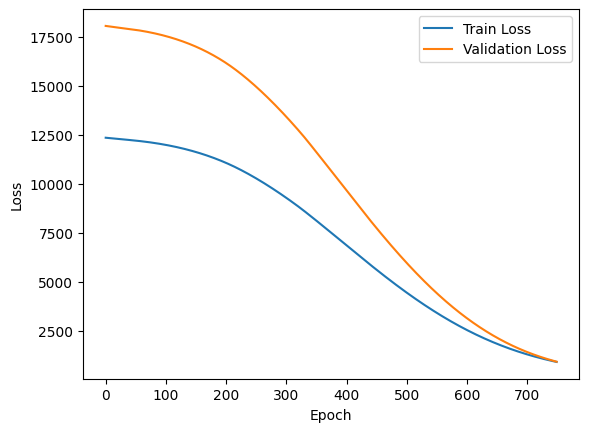

In [30]:
# load data 

import torch

df = load_lag_2_data()
target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

feature_names = df.drop(columns=[target_col]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    


# hyperparameters    
input_size = X_train_tensor.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 750

# initialize model
model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

# loss function
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# train
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    ### training
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    ### validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {loss.item():.4f}, "
         f"Val Loss: {val_loss.item():.4f}")
    
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# save figure
plt.savefig('../Figures/training_validation_loss.png')
plt.show()

In [31]:
df

,total_fresh_weight_g,carbon_dioxide,electrical_conductivity,temp_env,temp_nutr,humidity,pressure,weight_lag_1,weight_lag_2
0,49.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,46.0,29.7
1,46.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,47.0,30.1
2,51.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,47.0,31.8
3,42.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,38.1,29.3
4,50.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,42.0,30.2
5,46.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,43.0,29.1
6,46.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,46.0,43.0
7,44.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,41.3,30.4
8,50.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,45.0,29.8
9,46.0,-0.510252,-0.347143,0.091212,1.131556,0.091056,-0.222485,43.0,29.6


Baseline RMSE: 30.290106

Permutation results (20-repeat average):
weight_lag_1               RMSE=42.7423  (Δ=+12.4522,  sd=3.0167)
weight_lag_2               RMSE=42.0810  (Δ=+11.7909,  sd=2.6513)
temp_nutr                  RMSE=39.8137  (Δ=+9.5236,  sd=2.6114)
pressure                   RMSE=38.0289  (Δ=+7.7388,  sd=1.6924)
electrical_conductivity    RMSE=37.9007  (Δ=+7.6106,  sd=2.7476)
humidity                   RMSE=35.5679  (Δ=+5.2778,  sd=2.2409)
temp_env                   RMSE=34.9067  (Δ=+4.6166,  sd=2.0679)
carbon_dioxide             RMSE=34.6024  (Δ=+4.3123,  sd=2.8524)


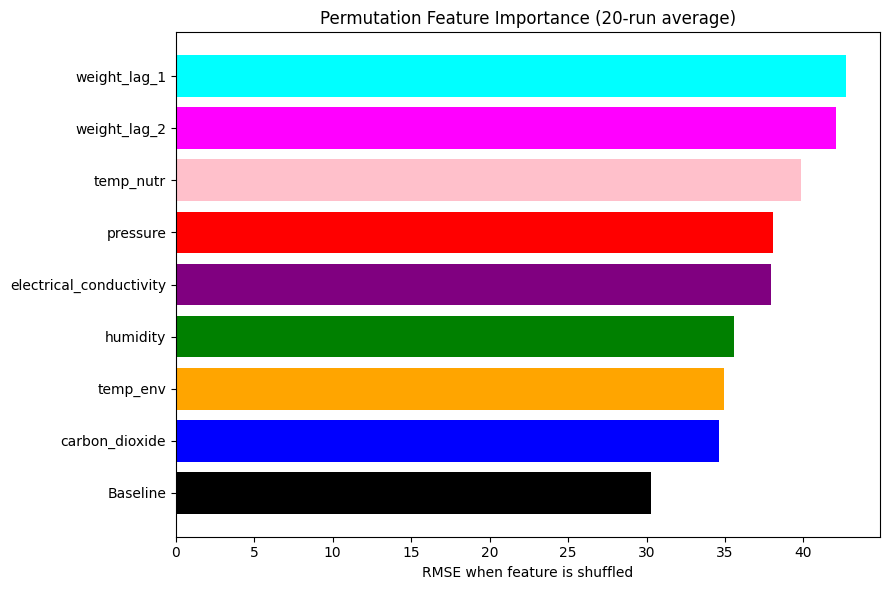

In [32]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# Set random seeds
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (n repeats)
# ==============================
repeats = 20
perm_results = []

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print(f"\nPermutation results ({repeats}-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title(f"Permutation Feature Importance ({repeats}-run average)")
plt.tight_layout()

plt.savefig('../Figures/trial_2_permutation_importance.png', bbox_inches='tight')
plt.show()

shows importance for automation per var


# Sensitivity analysis 


## Changes in electrical conductivity 
* We will modify the EC values by +-10 percent and observe the changes in model's predictions. 

In [33]:
# baseline predictions

# fucntion that returns list of predictions after feature perturbation
def get_perturbed_predictions(model, X_test_tensor, feature_name, perturbation=0.1):
    with torch.no_grad():
        baseline_preds = model(X_test_tensor)

        X_perturbed = X_test_tensor.clone()
        X_perturbed[:, feature_names.index(feature_name)] *= (1 + perturbation)

        perturbed_preds = model(X_perturbed)

    return baseline_preds, perturbed_preds


get_perturbed_predictions(model, X_test_tensor, 'electrical_conductivity', perturbation=0.1)


perturbation_results = []

for feature in feature_names:

    baseline_preds, perturbed_plus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.1
    )

    _, perturbed_minus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.1
    )

    _, perturbed_plus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.2
    )

    _, perturbed_minus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.2
    )

    _, perturbed_plus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.5
    )

    _, perturbed_minus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.5
    )

    _, perturbed_plus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.8
    )

    _, perturbed_minus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.8
    )

    plus_10_effect = (perturbed_plus_10 - baseline_preds).mean().item()
    minus_10_effect = (perturbed_minus_10 - baseline_preds).mean().item()
    plus_20_effect = (perturbed_plus_20 - baseline_preds).mean().item()
    minus_20_effect = (perturbed_minus_20 - baseline_preds).mean().item()
    plus_50_effect = (perturbed_plus_50 - baseline_preds).mean().item()
    minus_50_effect = (perturbed_minus_50 - baseline_preds).mean().item()
    plus_80_effect = (perturbed_plus_80 - baseline_preds).mean().item()
    minus_80_effect = (perturbed_minus_80 - baseline_preds).mean().item()

    perturbation_results.append({
        "feature": feature,
        "+10% effect (g)": plus_10_effect,
        "-10% effect (g)": minus_10_effect,
        "+20% effect (g)": plus_20_effect,
        "-20% effect (g)": minus_20_effect,
        "+50% effect (g)": plus_50_effect,
        "-50% effect (g)": minus_50_effect,
        "+80% effect (g)": plus_80_effect,
        "-80% effect (g)": minus_80_effect
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df = perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

perturbation_df = perturbation_df.round(4)

perturbation_df


,feature,+10% effect (g),-10% effect (g),+20% effect (g),-20% effect (g),+50% effect (g),-50% effect (g),+80% effect (g),-80% effect (g)
0,weight_lag_1,1.2663,-1.2620,2.5371,-2.5198,6.3594,-6.2224,10.2226,-9.8601
1,pressure,1.2158,-1.2159,2.4335,-2.4297,6.0910,-6.0679,9.7493,-9.6875
2,weight_lag_2,1.1830,-1.1816,2.3707,-2.3524,5.9613,-5.7322,9.6441,-8.8807
3,temp_env,0.9811,-0.9777,1.9671,-1.9507,4.9775,-4.8156,8.0914,-7.5598
4,humidity,0.9652,-0.9655,1.9331,-1.9287,4.8425,-4.8051,7.7756,-7.6516
5,temp_nutr,0.8121,-0.7857,1.6319,-1.5085,4.3772,-3.2511,7.3393,-4.3876
6,electrical_conductivity,0.6149,-0.6141,1.2624,-1.2246,3.2667,-3.0000,5.3428,-4.7286
7,carbon_dioxide,0.5301,-0.5167,1.0859,-1.0286,2.8904,-2.4715,4.8003,-3.7270


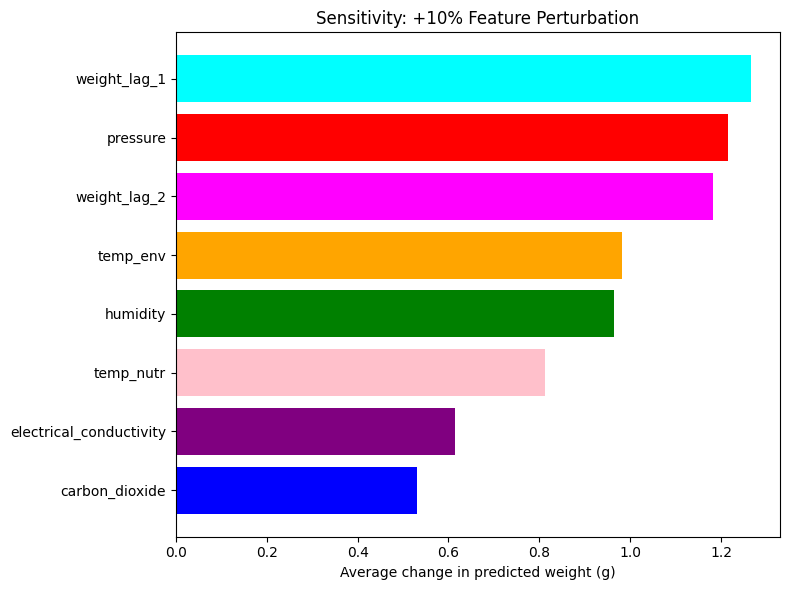

In [34]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+10% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +10% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

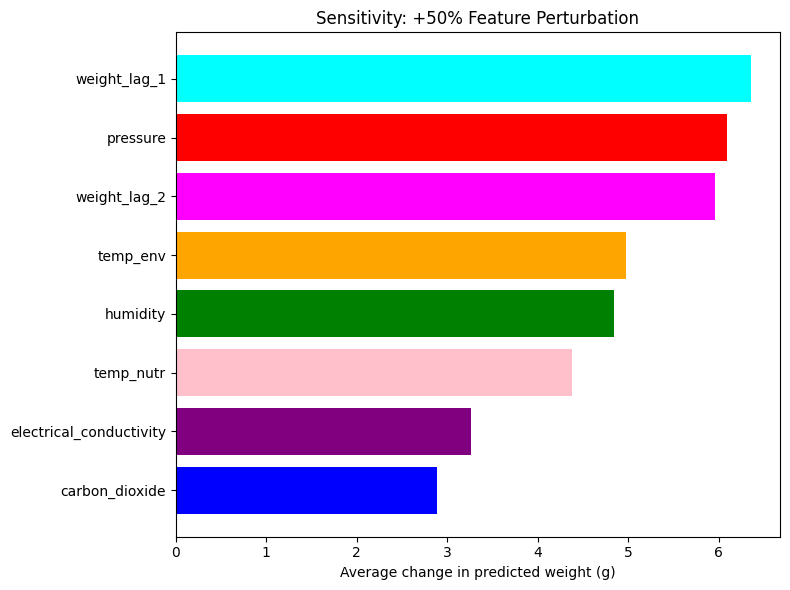

In [35]:
import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+50% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +50% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

In [36]:
feature_names

['carbon_dioxide',
 'electrical_conductivity',
 'temp_env',
 'temp_nutr',
 'humidity',
 'pressure',
 'weight_lag_1',
 'weight_lag_2']

In [37]:
X_perturbed

NameError: name 'X_perturbed' is not defined

## 

# Ablation study 

REMOVING FEATURE: carbon_dioxide
Feature removed: carbon_dioxide
RMSE: 11.1713


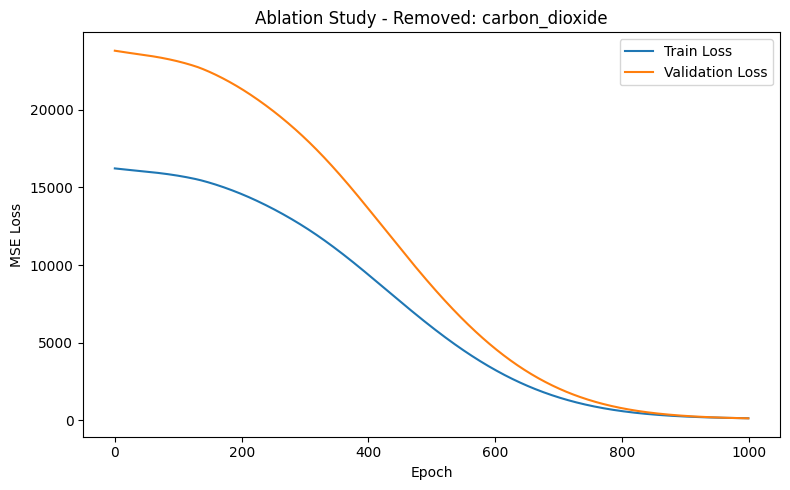

REMOVING FEATURE: temp_env
Feature removed: temp_env
RMSE: 15.1467


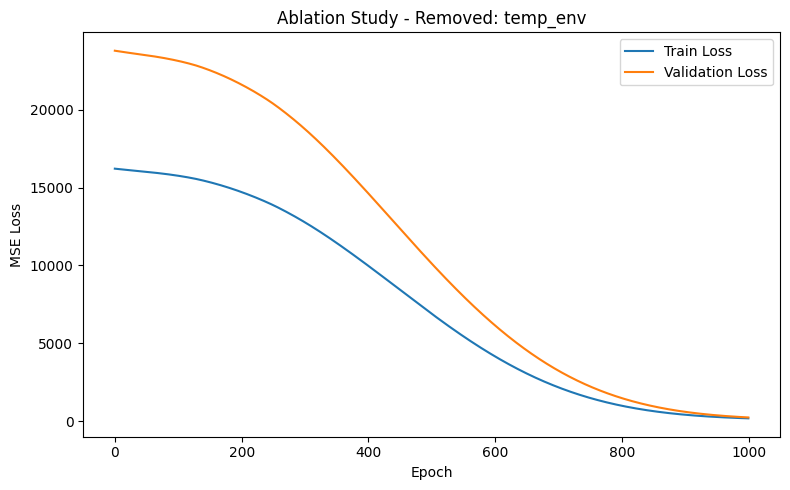

REMOVING FEATURE: humidity
Feature removed: humidity
RMSE: 12.1438


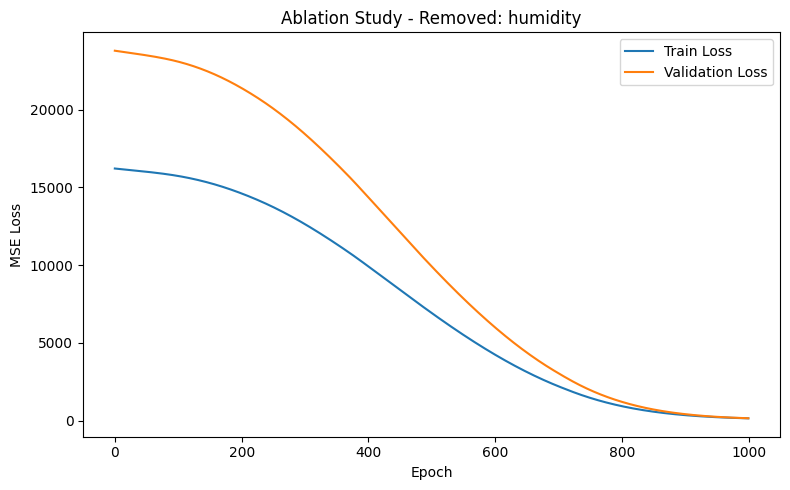

REMOVING FEATURE: pressure
Feature removed: pressure
RMSE: 14.1742


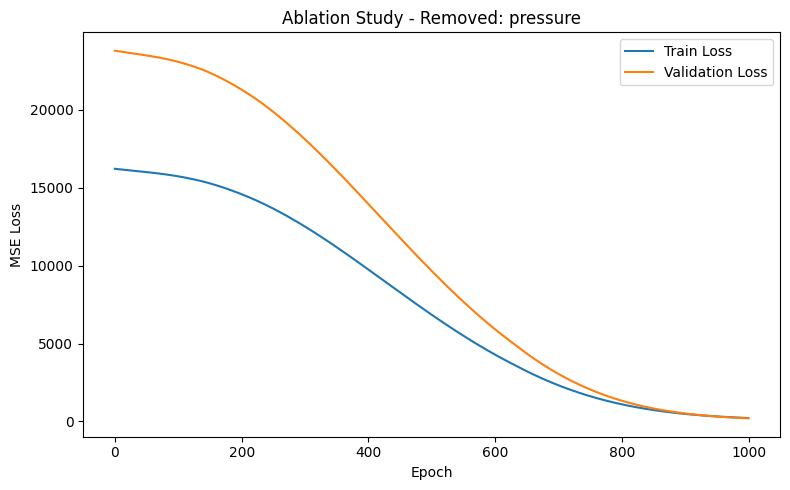

REMOVING FEATURE: electrical_conductivity
Feature removed: electrical_conductivity
RMSE: 13.3740


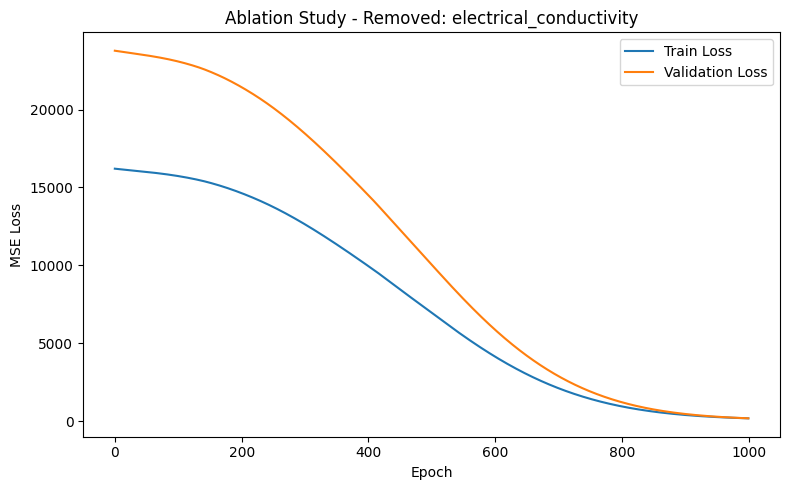

REMOVING FEATURE: volume
Feature removed: volume
RMSE: 13.5410


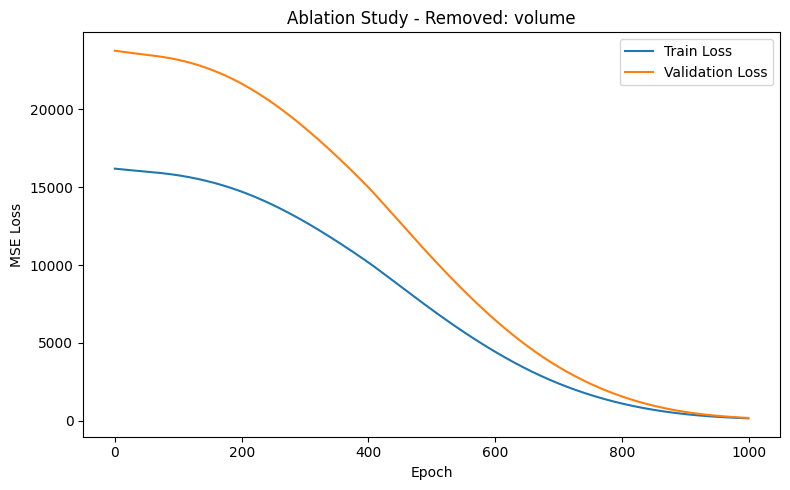

REMOVING FEATURE: temp_nutr
Feature removed: temp_nutr
RMSE: 15.5705


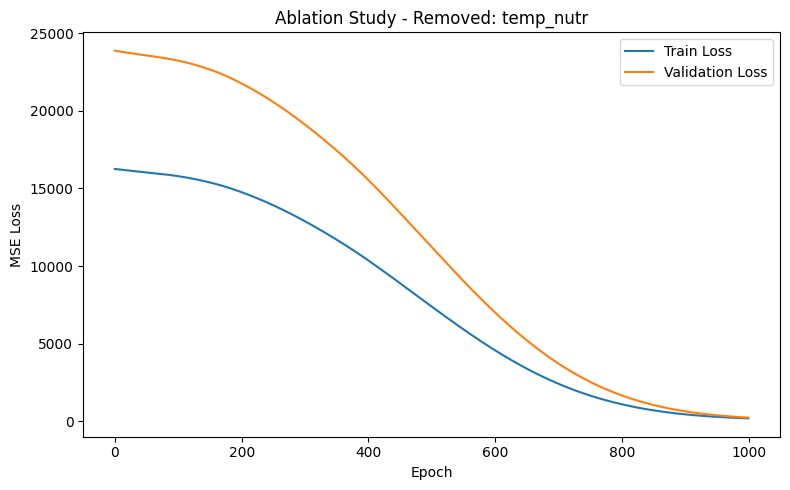

REMOVING FEATURE: volume_flow_rate
Feature removed: volume_flow_rate
RMSE: 16.2626


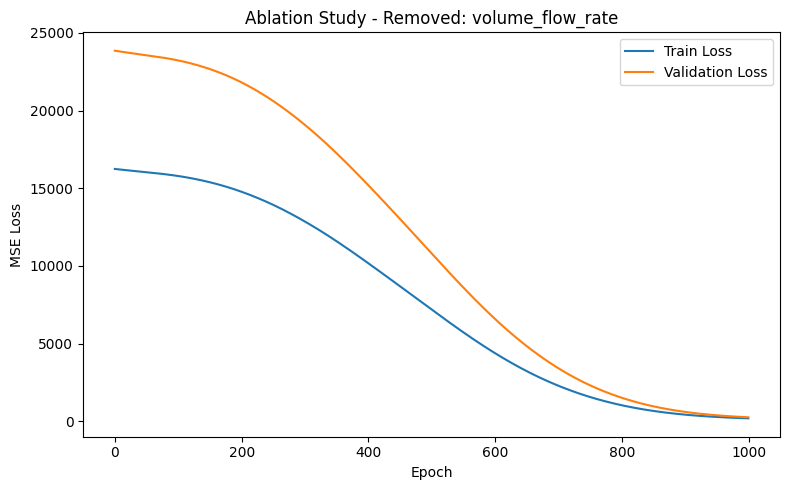

REMOVING FEATURE: weight_lag_1
Feature removed: weight_lag_1
RMSE: 13.0554


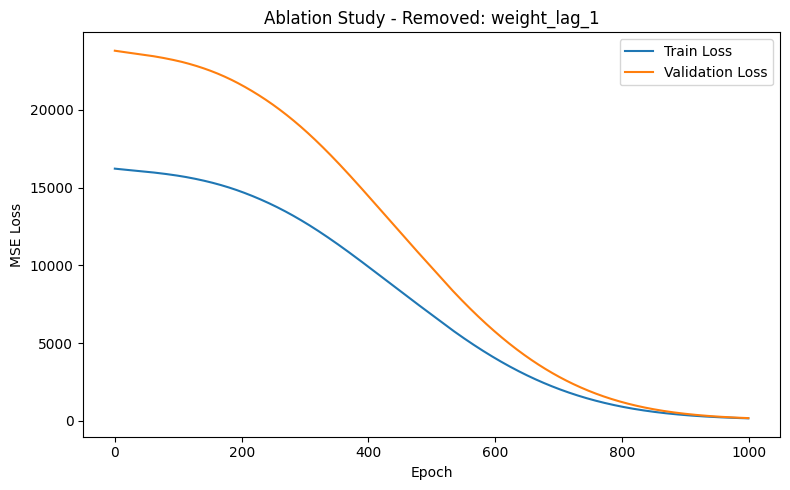

REMOVING FEATURE: weight_lag_2
Feature removed: weight_lag_2
RMSE: 14.5778


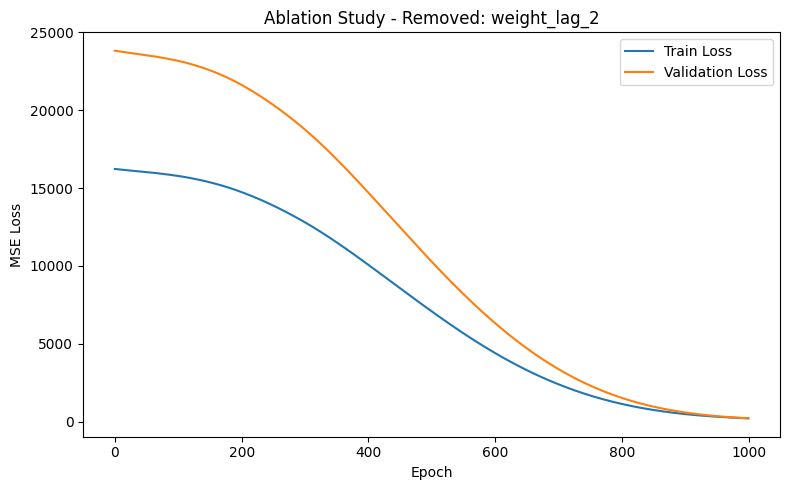


Ablation study summary:
           feature_removed       rmse
0         volume_flow_rate  16.262589
1                temp_nutr  15.570484
2                 temp_env  15.146693
3             weight_lag_2  14.577844
4                 pressure  14.174159
5                   volume  13.540987
6  electrical_conductivity  13.373953
7             weight_lag_1  13.055375
8                 humidity  12.143840
9           carbon_dioxide  11.171263


In [ ]:
# === Ablation study: remove one feature at a time, retrain, plot losses, print RMSE ===

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv('../Data/modeling_data.csv')

target_col = 'total_fresh_weight_g'
all_features = df.drop(columns=[target_col]).columns.tolist()


# -----------------------------
# Model
# -----------------------------
class BasicNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# -----------------------------
# Same hyperparameters/settings
# -----------------------------
hidden_size = 32
output_size = 1
learning_rate = 0.001
num_epochs = 1000


# -----------------------------
# Store ablation results
# -----------------------------
ablation_results = []


# -----------------------------
# Loop through each feature removal
# -----------------------------
for feature_removed in all_features:
    print("=" * 80)
    print(f"REMOVING FEATURE: {feature_removed}")

    # 
    kept_features = [f for f in all_features if f != feature_removed]

    X = df[kept_features].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

    # 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # s
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    # tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    # re-seed before each model so runs are comparable
    set_seed(42)

    # fresh model each time
    input_size = X_train_tensor.shape[1]
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    # train
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_tensor)
            val_loss = criterion(val_outputs, y_test_tensor)

        val_losses.append(val_loss.item())

    # final predictions + RMSE
    model.eval()
    with torch.no_grad():
        final_preds = model(X_test_tensor).numpy()

    rmse = np.sqrt(mean_squared_error(y_test, final_preds))

    print(f"Feature removed: {feature_removed}")
    print(f"RMSE: {rmse:.4f}")

    ablation_results.append({
        "feature_removed": feature_removed,
        "rmse": rmse
    })

    # plot losses for this ablation run
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Ablation Study - Removed: {feature_removed}")
    plt.legend()
    plt.tight_layout()

    # optional save
    safe_name = feature_removed.replace("/", "_")
    plt.savefig(f"../Figures/ablation_removed_{safe_name}.png")
    plt.show()


# -----------------------------
# Final summary dataframe
# -----------------------------
ablation_df = pd.DataFrame(ablation_results).sort_values("rmse", ascending=False).reset_index(drop=True)

print("\nAblation study summary:")
print(ablation_df)

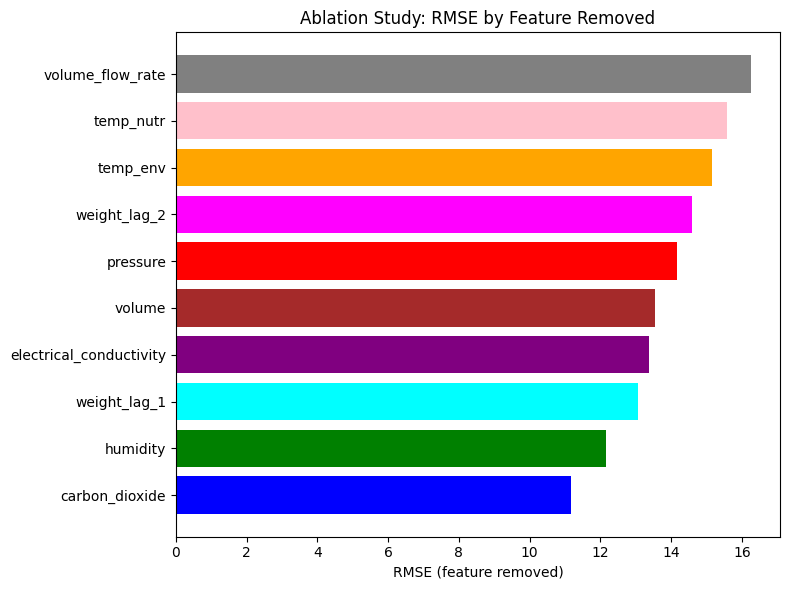

In [ ]:
# === Plot RMSE for each feature removed 

colors = ablation_df["feature_removed"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    ablation_df["feature_removed"],
    ablation_df["rmse"],
    color=colors
)

plt.xlabel("RMSE (feature removed)")
plt.title("Ablation Study: RMSE by Feature Removed")

plt.gca().invert_yaxis()  # highest RMSE at top

plt.tight_layout()
plt.savefig("../Figures/ablation_rmse_by_feature.png")
plt.show()